# Lesion-Based (Calcification, Mass) Training Experiments for all CNNs

**Image Preprocessing Pipeline:** Baseline (from image preprocessing experiment results)

**Image View:** CC-Only-View (from view-specific training experiment results)

* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 786, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 786 (delta 35), reused 75 (delta 26), pack-reused 693 (from 2)
Receiving objects: 100% (786/786), 24.91 MiB | 31.53 MiB/s, done.
Resolving deltas: 100% (378/378), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.experimental_results_functions import generate_lesion_results_metrics_df, store_experiment_results
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, CLASSIFICATION_THRESHOLD, EXPERIMENTAL_EPOCHS

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# Calcification-only lesion with CC-Only view
train_df_c = train_df.loc[(train_df['abnormality type'] == 'calcification') & (train_df['image view'] == 'CC')]
val_df_c = val_df.loc[(val_df['abnormality type'] == 'calcification') & (val_df['image view'] == 'CC')]

In [ ]:
# Class distributions for Calcification
print(train_df_c['pathology'].value_counts())
print(val_df_c['pathology'].value_counts())

pathology
0.0    360
1.0    187
Name: count, dtype: int64
pathology
0.0    106
1.0     48
Name: count, dtype: int64


In [ ]:
# Mass-only lesion with CC-Only view
train_df_m = train_df.loc[(train_df['abnormality type'] == 'mass') & (train_df['image view'] == 'CC')]
val_df_m = val_df.loc[(val_df['abnormality type'] == 'mass') & (val_df['image view'] == 'CC')]

In [ ]:
# Class distributions for Mass
print(train_df_m['pathology'].value_counts())
print(val_df_m['pathology'].value_counts())

pathology
0.0    280
1.0    236
Name: count, dtype: int64
pathology
0.0    62
1.0    58
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels_c = val_df_c['pathology'].to_numpy()
val_true_labels_m = val_df_m['pathology'].to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/lesions_experiment_results.csv"

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE_C = len(train_df_c)
BUFFER_SIZE_M = len(train_df_m)
# No. of training samples in Calcification and Mass dataframes for class weight
TOTAL_TRAINING_SAMPLES_C = len(train_df_c)
TOTAL_TRAINING_SAMPLES_M = len(train_df_m)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict_c = generate_class_weight_dict(train_df_c, CLASSES, TOTAL_TRAINING_SAMPLES_C)
class_weights_dict_m = generate_class_weight_dict(train_df_m, CLASSES, TOTAL_TRAINING_SAMPLES_M)

In [ ]:
# Image preprocessor
baseline_preprocessor = IMAGE_PREPROCESSORS['baseline']

## Calcification lesion only Experiment (with CC-Only-View and CLAHE + Median Blur Preprocessor)

#### tf.data Datasets for Calcification-Only Lesion

In [ ]:
# Generate training and validation datasets for Calcification only
train_dataset_c = dataset_preparation(train_df_c, baseline_preprocessor, BUFFER_SIZE_C, BATCH_SIZE, training=True)
val_dataset_c = dataset_preparation(val_df_c, baseline_preprocessor, BUFFER_SIZE_C, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_c = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_c, train_time_vgg16_c, peak_memory_vgg16_c = train_selected_model(vgg16_model_c,
                                                                        train_dataset_c,
                                                                        val_dataset_c,
                                                                        EXPERIMENTAL_EPOCHS,
                                                                        early_stopping,
                                                                        class_weights_dict_c)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 526ms/step - auc: 0.3164 - loss: 1.0382 - precision: 0.2995 - recall: 0.3476 - val_auc: 0.2729 - val_loss: 0.7532 - val_precision: 0.1600 - val_recall: 0.0833
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 457ms/step - auc: 0.3462 - loss: 0.8767 - precision: 0.3564 - recall: 0.3583 - val_auc: 0.4018 - val_loss: 0.6187 - val_precision: 0.4643 - val_recall: 0.2708
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 526ms/step - auc: 0.3723 - loss: 0.8258 - precision: 0.3782 - recall: 0.3155 - val_auc: 0.4500 - val_loss: 0.6035 - val_precision: 0.4750 - val_recall: 0.3958
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 525ms/step - auc: 0.4521 - loss: 0.7338 - precision: 0.4667 - recall: 0.5241 - val_auc: 0.4956 - val_loss: 0.5716 - val_precision: 0.5455 - val_recall: 0.3750
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 478ms/step - auc: 0.4322 - loss: 0.7126 - precision: 0.4541 - recall: 0.4759 - val_auc: 0.5217 - val_lo

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, preds_vgg16_c, metrics_dict_vgg16_c, infer_time_vgg16_c = generate_predictions_and_evaluations(vgg16_c, val_dataset_c, val_true_labels_c, CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - auc: 0.4898 - loss: 0.5296 - precision: 0.6316 - recall: 0.2500


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_c_results_df = generate_lesion_results_metrics_df(
    model_name='VGG16',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_vgg16_c,
    train_time=train_time_vgg16_c,
    infer_time=infer_time_vgg16_c,
    peak_memory=peak_memory_vgg16_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_c_results_df)

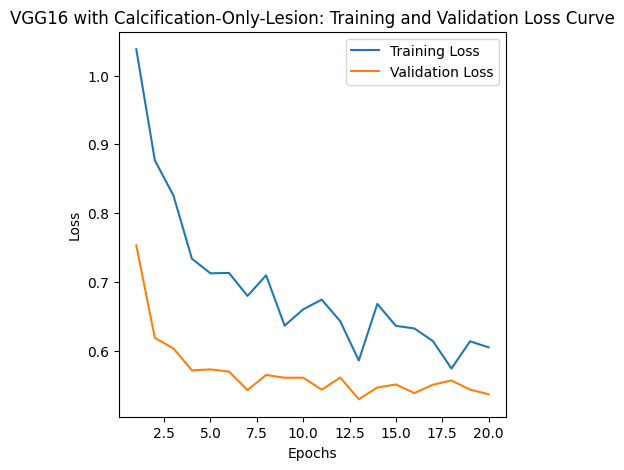

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_c.history, 'VGG16', 'Calcification-Only-Lesion')

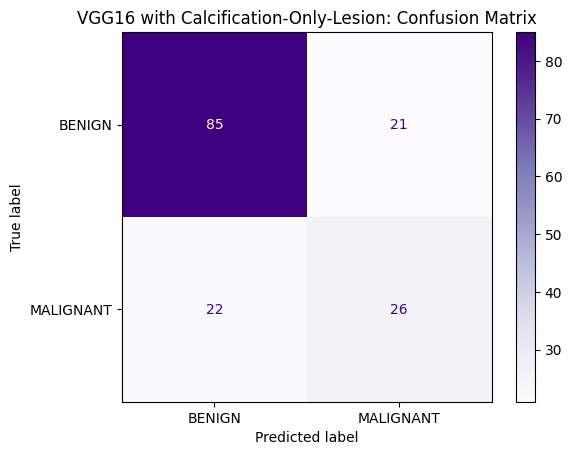

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_vgg16_c, 'VGG16', 'Calcification-Only-Lesion')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_c = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_c, train_time_resnet50_c, peak_memory_resnet50_c = train_selected_model(resnet50_model_c,
                                                                                 train_dataset_c,
                                                                                 val_dataset_c,
                                                                                 EXPERIMENTAL_EPOCHS,
                                                                                 early_stopping,
                                                                                 class_weights_dict_c)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 25s 665ms/step - auc: 0.4002 - loss: 0.7240 - precision: 0.4302 - recall: 0.3957 - val_auc: 0.4500 - val_loss: 0.5283 - val_precision: 0.5238 - val_recall: 0.2292
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 504ms/step - auc: 0.5163 - loss: 0.6219 - precision: 0.5667 - recall: 0.4545 - val_auc: 0.4838 - val_loss: 0.5554 - val_precision: 0.5227 - val_recall: 0.4792
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 530ms/step - auc: 0.5354 - loss: 0.5815 - precision: 0.5446 - recall: 0.5882 - val_auc: 0.4552 - val_loss: 0.5037 - val_precision: 0.5714 - val_recall: 0.2500
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 489ms/step - auc: 0.4788 - loss: 0.6176 - precision: 0.5278 - recall: 0.4064 - val_auc: 0.5224 - val_loss: 0.5420 - val_precision: 0.5455 - val_recall: 0.5000
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 454ms/step - auc: 0.5358 - loss: 0.5750 - precision: 0.5485 - recall: 0.6043 - val_auc: 0.4669 - val_lo

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, preds_resnet50_c, metrics_dict_resnet50_c, infer_time_resnet50_c = generate_predictions_and_evaluations(resnet50_c, val_dataset_c, val_true_labels_c,
                                                                                                         CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 740ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - auc: 0.5292 - loss: 0.4904 - precision: 0.6207 - recall: 0.3750


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_c_results_df = generate_lesion_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_resnet50_c,
    train_time=train_time_resnet50_c,
    infer_time=infer_time_resnet50_c,
    peak_memory=peak_memory_resnet50_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_c_results_df)

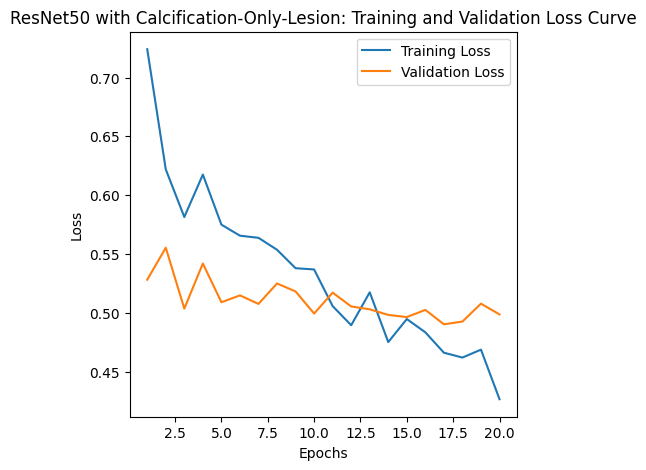

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_c.history, 'ResNet50', 'Calcification-Only-Lesion')

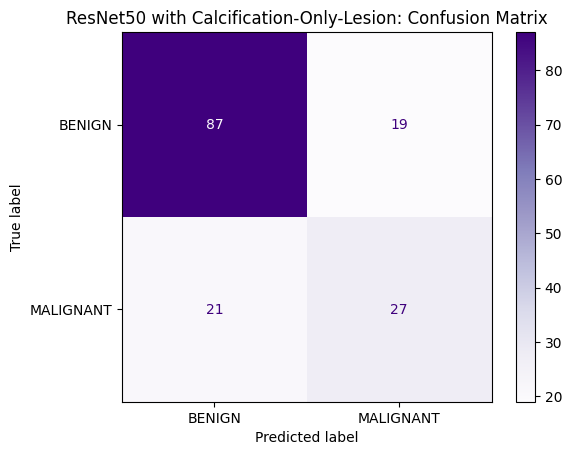

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_resnet50_c, 'ResNet50', 'Calcification-Only-Lesion')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_c = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_c, train_time_densenet121_c, peak_memory_densenet121_c = train_selected_model(densenet121_model_c,
                                                                                          train_dataset_c,
                                                                                          val_dataset_c,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_c)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 34s 840ms/step - auc: 0.3766 - loss: 0.7187 - precision: 0.3805 - recall: 0.2299 - val_auc: 0.5223 - val_loss: 0.6319 - val_precision: 0.5882 - val_recall: 0.4167
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 541ms/step - auc: 0.4381 - loss: 0.6426 - precision: 0.4497 - recall: 0.3583 - val_auc: 0.5284 - val_loss: 0.5634 - val_precision: 0.6000 - val_recall: 0.3750
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 534ms/step - auc: 0.4926 - loss: 0.6112 - precision: 0.5141 - recall: 0.3904 - val_auc: 0.5308 - val_loss: 0.5690 - val_precision: 0.5526 - val_recall: 0.4375
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 527ms/step - auc: 0.4809 - loss: 0.6276 - precision: 0.4933 - recall: 0.3957 - val_auc: 0.5401 - val_loss: 0.5504 - val_precision: 0.6000 - val_recall: 0.4375
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 471ms/step - auc: 0.4752 - loss: 0.6225 - precision: 0.5111 - recall: 0.3690 - val_auc: 0.5144 - val_lo

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, preds_densenet121_c, metrics_dict_densenet121_c, infer_time_densenet121_c = generate_predictions_and_evaluations(densenet121_c, val_dataset_c, val_true_labels_c,
                                                                                                                    CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - auc: 0.5524 - loss: 0.4847 - precision: 0.5926 - recall: 0.3333


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_c_results_df = generate_lesion_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_densenet121_c,
    train_time=train_time_densenet121_c,
    infer_time=infer_time_densenet121_c,
    peak_memory=peak_memory_densenet121_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_c_results_df)

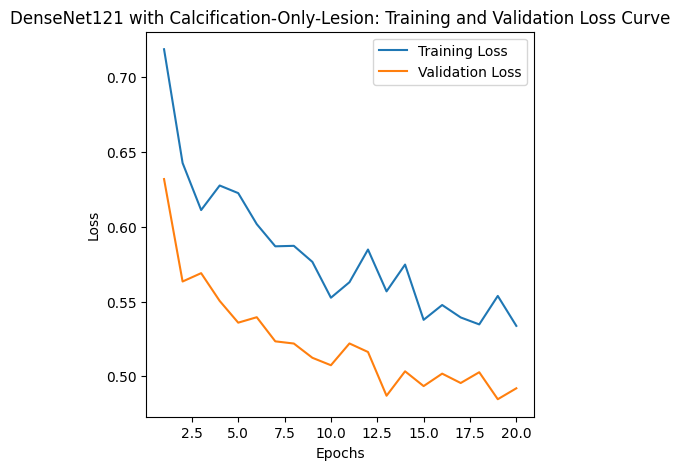

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_c.history, 'DenseNet121', 'Calcification-Only-Lesion')

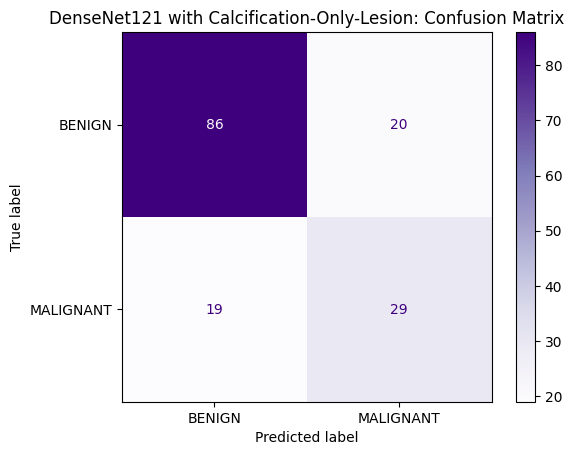

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_densenet121_c, 'DenseNet121', 'Calcification-Only-Lesion')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_c = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_c, train_time_mobilenetv2_c, peak_memory_mobilenetv2_c = train_selected_model(mobilenetv2_model_c,
                                                                                          train_dataset_c,
                                                                                          val_dataset_c,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_c)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 568ms/step - auc: 0.3805 - loss: 0.7837 - precision: 0.3873 - recall: 0.3583 - val_auc: 0.5010 - val_loss: 0.6601 - val_precision: 0.4808 - val_recall: 0.5208
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 390ms/step - auc: 0.4605 - loss: 0.6538 - precision: 0.4832 - recall: 0.3850 - val_auc: 0.5184 - val_loss: 0.5910 - val_precision: 0.4884 - val_recall: 0.4375
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 400ms/step - auc: 0.5085 - loss: 0.6292 - precision: 0.5392 - recall: 0.5882 - val_auc: 0.5255 - val_loss: 0.5678 - val_precision: 0.5714 - val_recall: 0.5000
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 457ms/step - auc: 0.5213 - loss: 0.6081 - precision: 0.5850 - recall: 0.4599 - val_auc: 0.5154 - val_loss: 0.6449 - val_precision: 0.4643 - val_recall: 0.5417
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 383ms/step - auc: 0.5262 - loss: 0.6006 - precision: 0.5491 - recall: 0.5080 - val_auc: 0.5422 - val_loss: 

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, preds_mobilenetv2_c, metrics_dict_mobilenetv2_c, infer_time_mobilenetv2_c = generate_predictions_and_evaluations(mobilenetv2_c, val_dataset_c, val_true_labels_c,
                                                                                                                    CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 423ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - auc: 0.5216 - loss: 0.5308 - precision: 0.6098 - recall: 0.5208


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_c_results_df = generate_lesion_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_mobilenetv2_c,
    train_time=train_time_mobilenetv2_c,
    infer_time=infer_time_mobilenetv2_c,
    peak_memory=peak_memory_mobilenetv2_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_c_results_df)

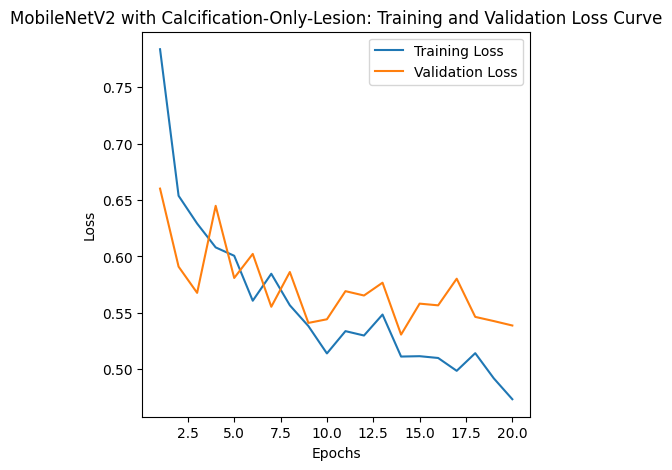

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_c.history, 'MobileNetV2', 'Calcification-Only-Lesion')

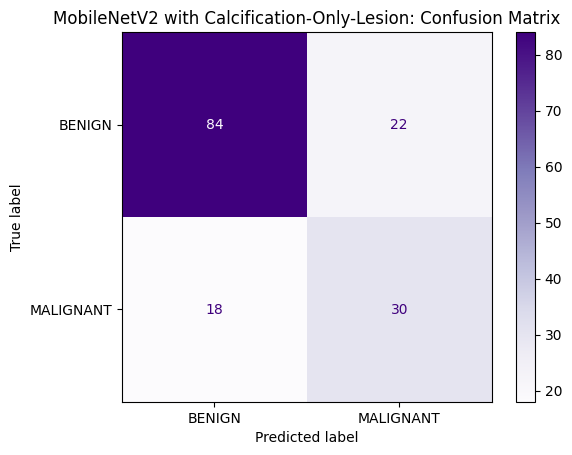

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_mobilenetv2_c, 'MobileNetV2', 'Calcification-Only-Lesion')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_c = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_c, train_time_efficientnetb0_c, peak_memory_efficientnetb0_c = train_selected_model(efficientnetb0_model_c,
                                                                                                   train_dataset_c,
                                                                                                   val_dataset_c,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict_c)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 27s 642ms/step - auc: 0.3620 - loss: 0.7019 - precision: 0.3968 - recall: 0.1337 - val_auc: 0.4071 - val_loss: 0.6377 - val_precision: 1.0000 - val_recall: 0.0417
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 479ms/step - auc: 0.4991 - loss: 0.6349 - precision: 0.5484 - recall: 0.1818 - val_auc: 0.5329 - val_loss: 0.6217 - val_precision: 0.5667 - val_recall: 0.3542
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 468ms/step - auc: 0.5188 - loss: 0.6133 - precision: 0.5776 - recall: 0.3583 - val_auc: 0.5406 - val_loss: 0.5909 - val_precision: 0.5263 - val_recall: 0.4167
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 405ms/step - auc: 0.5037 - loss: 0.6144 - precision: 0.5179 - recall: 0.4652 - val_auc: 0.5160 - val_loss: 0.5675 - val_precision: 0.6333 - val_recall: 0.3958
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 457ms/step - auc: 0.5580 - loss: 0.6026 - precision: 0.5821 - recall: 0.4171 - val_auc: 0.5354 - val_los

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, preds_efficientnetb0_c, metrics_dict_efficientnetb0_c, infer_time_efficientnetb0_c = generate_predictions_and_evaluations(efficientnetb0_c, val_dataset_c,
                                                                                                                             val_true_labels_c,
                                                                                                                             CLASSIFICATION_THRESHOLD)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 660ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - auc: 0.5096 - loss: 0.5071 - precision: 0.6250 - recall: 0.3125


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_c_results_df = generate_lesion_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Calcification-Only-Lesion',
    eval_metrics=metrics_dict_efficientnetb0_c,
    train_time=train_time_efficientnetb0_c,
    infer_time=infer_time_efficientnetb0_c,
    peak_memory=peak_memory_efficientnetb0_c,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_c_results_df)

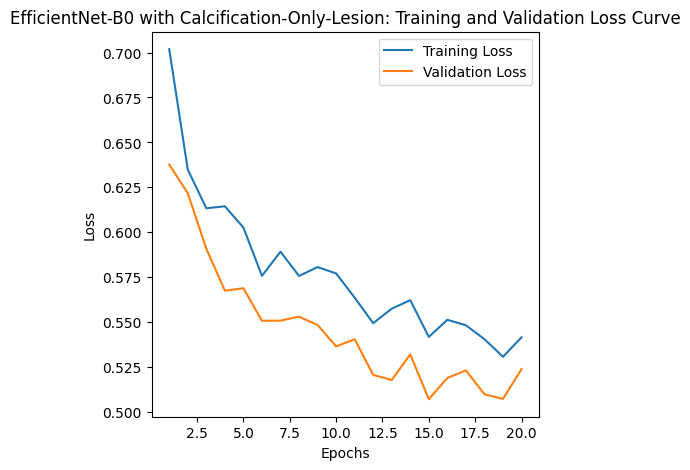

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_c.history, 'EfficientNet-B0', 'Calcification-Only-Lesion')

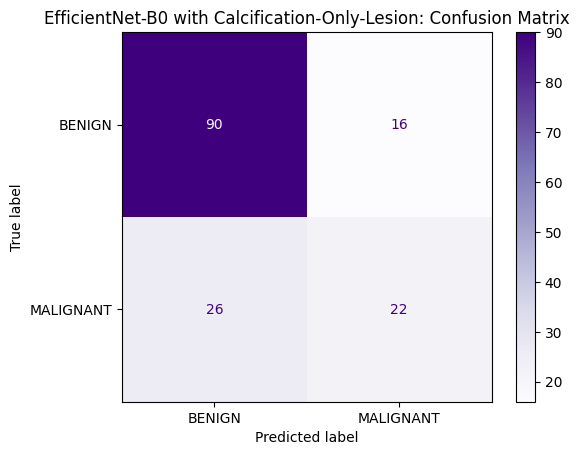

In [ ]:
plot_confusion_matrix(val_true_labels_c, preds_efficientnetb0_c, 'EfficientNet-B0', 'Calcification-Only-Lesion')

## Mass Lesion Only Experiment (with CC-Only-View and CLAHE + Median Blur Preprocessor)

#### tf.data Datasets for Mass-only Lesion

In [ ]:
# Generate training and validation datasets for Mass only
train_dataset_m = dataset_preparation(train_df_m, baseline_preprocessor, BUFFER_SIZE_M, BATCH_SIZE, training=True)
val_dataset_m = dataset_preparation(val_df_m, baseline_preprocessor, BUFFER_SIZE_M, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_m = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_m, train_time_vgg16_m, peak_memory_vgg16_m = train_selected_model(vgg16_model_m,
                                                                        train_dataset_m,
                                                                        val_dataset_m,
                                                                        EXPERIMENTAL_EPOCHS,
                                                                        early_stopping,
                                                                        class_weights_dict_m)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 550ms/step - auc: 0.4582 - loss: 0.8710 - precision: 0.4774 - recall: 0.4025 - val_auc: 0.5294 - val_loss: 0.7476 - val_precision: 0.6000 - val_recall: 0.1034
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 492ms/step - auc: 0.4554 - loss: 0.8788 - precision: 0.4604 - recall: 0.3941 - val_auc: 0.5528 - val_loss: 0.7009 - val_precision: 0.5333 - val_recall: 0.1379
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 422ms/step - auc: 0.5468 - loss: 0.7975 - precision: 0.5890 - recall: 0.3644 - val_auc: 0.5845 - val_loss: 0.7037 - val_precision: 0.7273 - val_recall: 0.1379
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 498ms/step - auc: 0.5183 - loss: 0.7923 - precision: 0.5106 - recall: 0.4068 - val_auc: 0.5934 - val_loss: 0.6725 - val_precision: 0.6400 - val_recall: 0.2759
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 436ms/step - auc: 0.5634 - loss: 0.7246 - precision: 0.5736 - recall: 0.4788 - val_auc: 0.6175 - val_loss: 

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, preds_vgg16_m, metrics_dict_vgg16_m, infer_time_vgg16_m = generate_predictions_and_evaluations(vgg16_m, val_dataset_m, val_true_labels_m, CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step - auc: 0.6798 - loss: 0.6490 - precision: 0.7143 - recall: 0.4310


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_m_results_df = generate_lesion_results_metrics_df(
    model_name='VGG16',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_vgg16_m,
    train_time=train_time_vgg16_m,
    infer_time=infer_time_vgg16_m,
    peak_memory=peak_memory_vgg16_m,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_m_results_df)

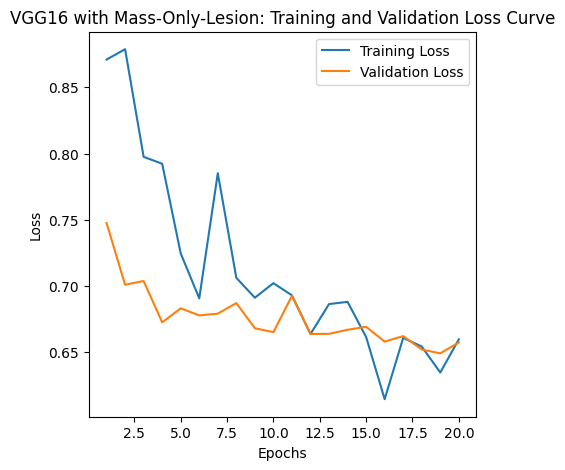

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_m.history, 'VGG16', 'Mass-Only-Lesion')

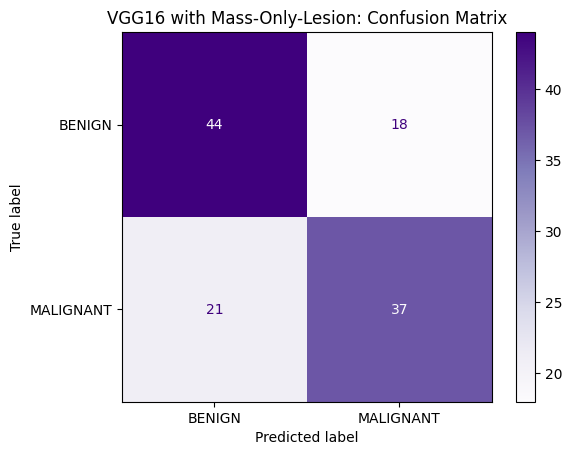

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_vgg16_m, 'VGG16', 'Mass-Only-Lesion')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_m = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_m, train_time_resnet50_m, peak_memory_resnet50_m = train_selected_model(resnet50_model_m,
                                                                                 train_dataset_m,
                                                                                 val_dataset_m,
                                                                                 EXPERIMENTAL_EPOCHS,
                                                                                 early_stopping,
                                                                                 class_weights_dict_m)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 651ms/step - auc: 0.5470 - loss: 0.7074 - precision: 0.5689 - recall: 0.4025 - val_auc: 0.6721 - val_loss: 0.6657 - val_precision: 0.8667 - val_recall: 0.2241
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 500ms/step - auc: 0.6219 - loss: 0.6794 - precision: 0.6694 - recall: 0.3517 - val_auc: 0.7161 - val_loss: 0.6414 - val_precision: 0.7179 - val_recall: 0.4828
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 424ms/step - auc: 0.6614 - loss: 0.6075 - precision: 0.6743 - recall: 0.5000 - val_auc: 0.7255 - val_loss: 0.6256 - val_precision: 0.8125 - val_recall: 0.4483
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 446ms/step - auc: 0.6900 - loss: 0.5955 - precision: 0.7102 - recall: 0.5297 - val_auc: 0.7306 - val_loss: 0.6168 - val_precision: 0.8182 - val_recall: 0.4655
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 487ms/step - auc: 0.6730 - loss: 0.5894 - precision: 0.7232 - recall: 0.5424 - val_auc: 0.7320 - val_loss:

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, preds_resnet50_m, metrics_dict_resnet50_m, infer_time_resnet50_m = generate_predictions_and_evaluations(resnet50_m, val_dataset_m, val_true_labels_m,
                                                                                                           CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 924ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - auc: 0.8020 - loss: 0.5694 - precision: 0.8293 - recall: 0.5862


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_m_results_df = generate_lesion_results_metrics_df(
    model_name='ResNet50',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_resnet50_m,
    train_time=train_time_resnet50_m,
    infer_time=infer_time_resnet50_m,
    peak_memory=peak_memory_resnet50_m,
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_m_results_df)

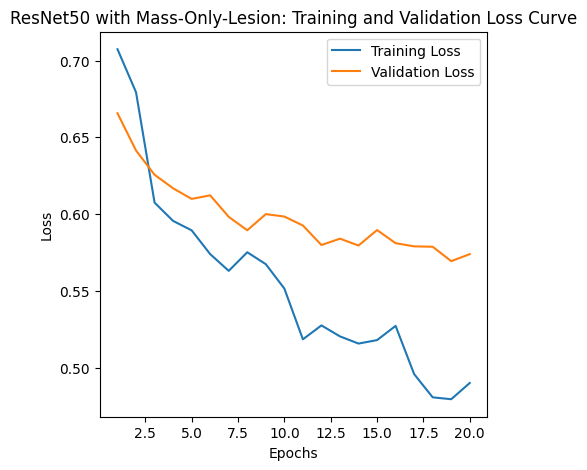

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_m.history, 'ResNet50', 'Mass-Only-Lesion')

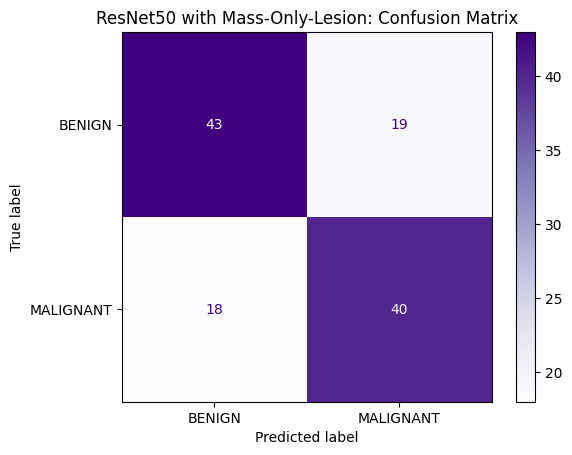

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_resnet50_m, 'ResNet50', 'Mass-Only-Lesion')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_m = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_m, train_time_densenet121_m, peak_memory_densenet121_m = train_selected_model(densenet121_model_m,
                                                                                          train_dataset_m,
                                                                                          val_dataset_m,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_m)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 31s 806ms/step - auc: 0.5119 - loss: 0.7122 - precision: 0.5368 - recall: 0.3093 - val_auc: 0.6221 - val_loss: 0.6705 - val_precision: 0.6667 - val_recall: 0.1724
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 508ms/step - auc: 0.5973 - loss: 0.6568 - precision: 0.6698 - recall: 0.3008 - val_auc: 0.6597 - val_loss: 0.6570 - val_precision: 0.6667 - val_recall: 0.3448
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 614ms/step - auc: 0.5684 - loss: 0.6567 - precision: 0.6159 - recall: 0.4280 - val_auc: 0.6561 - val_loss: 0.6416 - val_precision: 0.7407 - val_recall: 0.3448
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 445ms/step - auc: 0.6402 - loss: 0.6287 - precision: 0.6815 - recall: 0.4534 - val_auc: 0.6758 - val_loss: 0.6312 - val_precision: 0.7667 - val_recall: 0.3966
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 510ms/step - auc: 0.6506 - loss: 0.6148 - precision: 0.6516 - recall: 0.4280 - val_auc: 0.6817 - val_los

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, preds_densenet121_m, metrics_dict_densenet121_m, infer_time_densenet121_m = generate_predictions_and_evaluations(densenet121_m, val_dataset_m, val_true_labels_m,
                                                                                                                    CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - auc: 0.7258 - loss: 0.5937 - precision: 0.7429 - recall: 0.4483


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_m_results_df = generate_lesion_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_densenet121_m,
    train_time=train_time_densenet121_m,
    infer_time=infer_time_densenet121_m,
    peak_memory=peak_memory_densenet121_m
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_m_results_df)

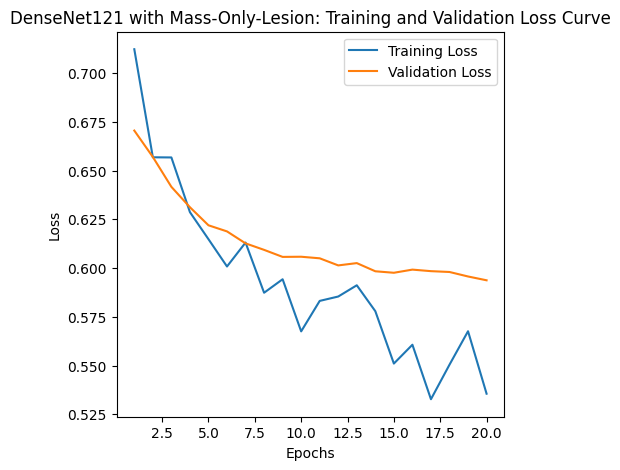

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_m.history, 'DenseNet121', 'Mass-Only-Lesion')

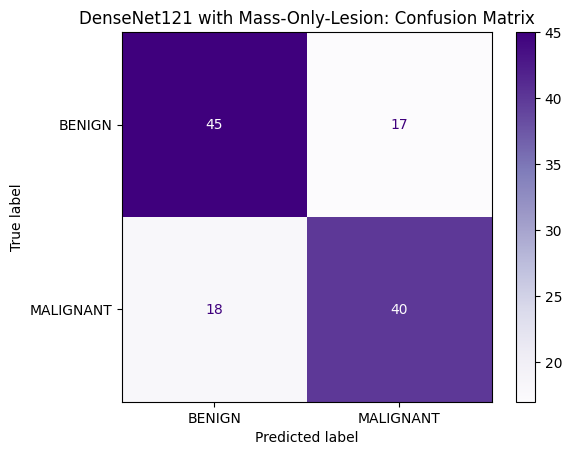

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_densenet121_m, 'DenseNet121', 'Mass-Only-Lesion')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_m = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_m, train_time_mobilenetv2_m, peak_memory_mobilenetv2_m = train_selected_model(mobilenetv2_model_m,
                                                                                          train_dataset_m,
                                                                                          val_dataset_m,
                                                                                          EXPERIMENTAL_EPOCHS,
                                                                                          early_stopping,
                                                                                          class_weights_dict_m)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 525ms/step - auc: 0.4956 - loss: 0.7613 - precision: 0.5238 - recall: 0.3729 - val_auc: 0.5613 - val_loss: 0.6669 - val_precision: 0.6154 - val_recall: 0.2759
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 462ms/step - auc: 0.5547 - loss: 0.7022 - precision: 0.6422 - recall: 0.2966 - val_auc: 0.6117 - val_loss: 0.6580 - val_precision: 0.6222 - val_recall: 0.4828
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 370ms/step - auc: 0.5905 - loss: 0.6790 - precision: 0.6009 - recall: 0.5551 - val_auc: 0.6391 - val_loss: 0.6359 - val_precision: 0.6429 - val_recall: 0.3103
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 452ms/step - auc: 0.6274 - loss: 0.6417 - precision: 0.6619 - recall: 0.3898 - val_auc: 0.6558 - val_loss: 0.6271 - val_precision: 0.6579 - val_recall: 0.4310
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 423ms/step - auc: 0.6094 - loss: 0.6482 - precision: 0.6507 - recall: 0.4025 - val_auc: 0.6610 - val_loss: 0

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, preds_mobilenetv2_m, metrics_dict_mobilenetv2_m, infer_time_mobilenetv2_m = generate_predictions_and_evaluations(mobilenetv2_m, val_dataset_m, val_true_labels_m,
                                                                                                                    CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 661ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - auc: 0.7106 - loss: 0.5850 - precision: 0.7838 - recall: 0.5000


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_m_results_df = generate_lesion_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_mobilenetv2_m,
    train_time=train_time_mobilenetv2_m,
    infer_time=infer_time_mobilenetv2_m,
    peak_memory=peak_memory_mobilenetv2_m
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_m_results_df)

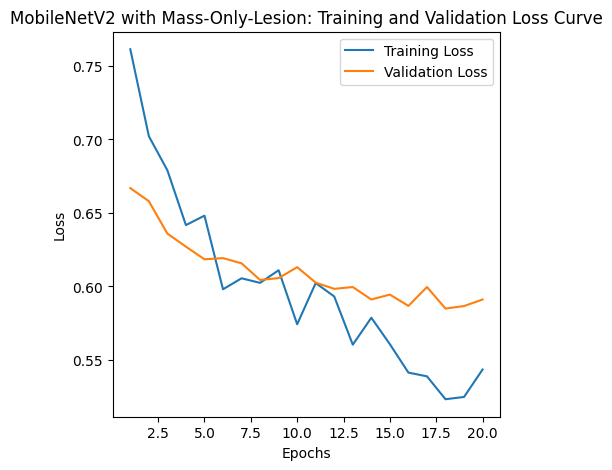

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_m.history, 'MobileNetV2', 'Mass-Only-Lesion')

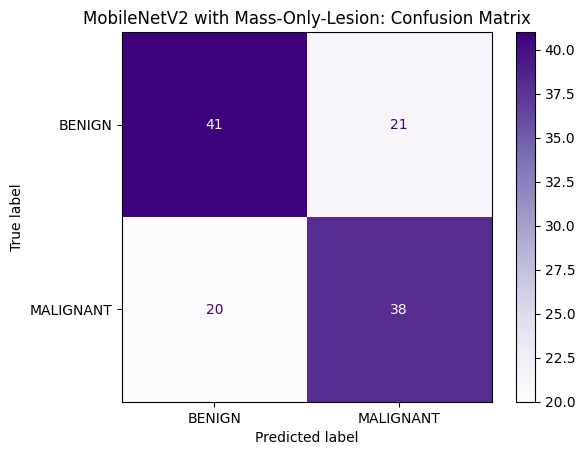

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_mobilenetv2_m, 'MobileNetV2', 'Mass-Only-Lesion')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_m = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_m, train_time_efficientnetb0_m, peak_memory_efficientnetb0_m = train_selected_model(efficientnetb0_model_m,
                                                                                                   train_dataset_m,
                                                                                                   val_dataset_m,
                                                                                                   EXPERIMENTAL_EPOCHS,
                                                                                                   early_stopping,
                                                                                                   class_weights_dict_m)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 26s 637ms/step - auc: 0.4412 - loss: 0.7064 - precision: 0.3846 - recall: 0.0847 - val_auc: 0.6696 - val_loss: 0.6730 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 393ms/step - auc: 0.5961 - loss: 0.6531 - precision: 0.6618 - recall: 0.1907 - val_auc: 0.6989 - val_loss: 0.6560 - val_precision: 0.8333 - val_recall: 0.1724
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 471ms/step - auc: 0.6377 - loss: 0.6430 - precision: 0.7500 - recall: 0.1907 - val_auc: 0.7014 - val_loss: 0.6460 - val_precision: 0.8333 - val_recall: 0.2586
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 386ms/step - auc: 0.6747 - loss: 0.6203 - precision: 0.6967 - recall: 0.3602 - val_auc: 0.7183 - val_loss: 0.6365 - val_precision: 0.8636 - val_recall: 0.3276
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 448ms/step - auc: 0.6732 - loss: 0.6250 - precision: 0.7677 - recall: 0.3220 - val_auc: 0.7239 - va

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, preds_efficientnetb0_m, metrics_dict_efficientnetb0_m, infer_time_efficientnetb0_m = generate_predictions_and_evaluations(efficientnetb0_m, val_dataset_m,
                                                                                                                             val_true_labels_m,
                                                                                                                             CLASSIFICATION_THRESHOLD)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - auc: 0.7513 - loss: 0.6107 - precision: 0.7879 - recall: 0.4483


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_m_results_df = generate_lesion_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='Mass-Only-Lesion',
    eval_metrics=metrics_dict_efficientnetb0_m,
    train_time=train_time_efficientnetb0_m,
    infer_time=infer_time_efficientnetb0_m,
    peak_memory=peak_memory_efficientnetb0_m
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_m_results_df)

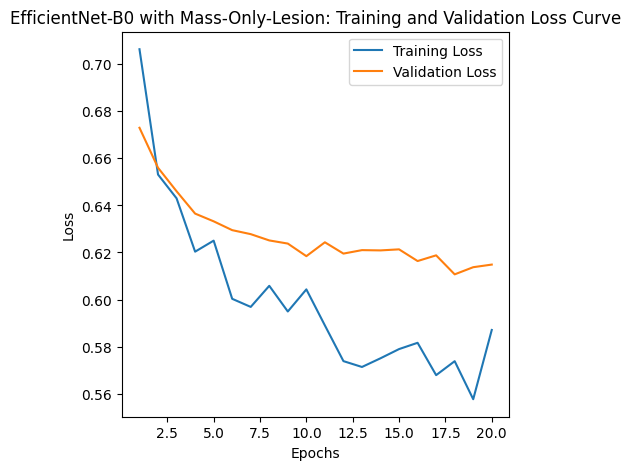

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_m.history, 'EfficientNet-B0', 'Mass-Only-Lesion')

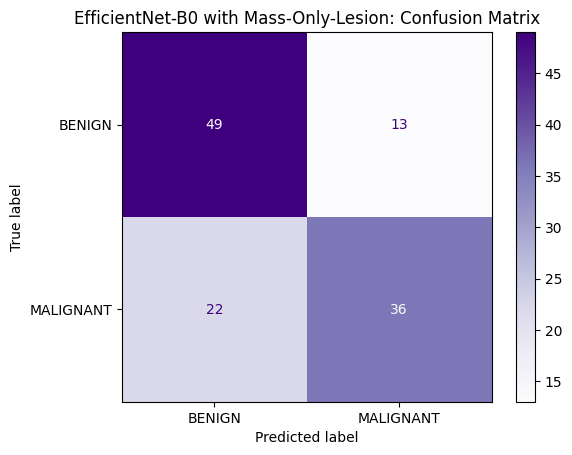

In [ ]:
plot_confusion_matrix(val_true_labels_m, preds_efficientnetb0_m, 'EfficientNet-B0', 'Mass-Only-Lesion')